# 🌊 End-to-End Machine Learning Pipeline: Global Drinking Water Potability & Quality Classification
**Course:** CSD 302 — Machine Learning I
**Project Track:** Data-Cleaning, Preprocessing Pipeline, Model Comparison & Ethical Evaluation*  
**Domain:** Environmental Data Science, Public Health & Sensor Telemetry  

---

## 📌 1. Executive Summary & Problem Formulation

Access to safe, uncontaminated drinking water is a fundamental human necessity and a major pillar of global public health (UN Sustainable Development Goal 6). Traditional laboratory water testing (microbiological culture and spectrometry) is accurate but slow, expensive, and difficult to deploy continuously at scale across distributed municipal networks.

### 🎯 Machine Learning Objective
The primary objective of this project is to construct a **robust, leak-free data cleaning and preprocessing pipeline** on an integrated, multi-source environmental water dataset and train a high-fidelity classification system to predict water potability:
$$\hat{y} \in \{0, 1\}$$
* **Class `0` (Non-Potable / Unsafe)**: Water contains chemical or physical contaminants exceeding health guidelines; unsafe for human consumption.
* **Class `1` (Potable / Safe)**: Water meets biochemical thresholds and is safe for human consumption.

---

## ⚠️ 2. Asymmetric Cost Matrix & Evaluation Philosophy

In clinical and environmental triage systems, classification errors are **not created equal**:

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│                                 COST OF ERROR ANALYSIS                                 │
├────────────────────────────────┬───────────────────────────────────────────────────────┤
│ 🔴 Type II Error (False Neg):  │ Model predicts "Potable" (1), but water is Toxic (0). │
│    CATASTROPHIC RISK           │ ➔ Results in severe disease outbreaks / poisoning.    │
├────────────────────────────────┼───────────────────────────────────────────────────────┤
│ 🟡 Type I Error (False Pos):   │ Model predicts "Toxic" (0), but water is Potable (1). │
│    OPERATIONAL INCONVENIENCE   │ ➔ Triggers redundant lab re-testing; zero health risk.│
└────────────────────────────────┴───────────────────────────────────────────────────────┘
```

> **Evaluation Mandate:** Because False Negatives present an existential health hazard, our model selection cannot rely on simple Accuracy. We will prioritize **Recall (Sensitivity)** on toxic samples, **F1-Score (Macro)**, and **Precision-Recall AUC (PR-AUC)** alongside ROC-AUC.

---

## 🗂️ 3. Integrated Dataset Architecture

To simulate real-world municipal water monitoring, we engineered a **Multi-Source Master Dataset** combining **7,776 observations** across two complementary data streams:

1. **Source A (Global Water Survey — 3,276 records)**: Benchmark physicochemical water body samples from diverse lakes, rivers, and reservoirs globally.
2. **Source B (Regional Sensor Telemetry Network — 4,500 records)**: High-frequency telemetry from automated environmental monitoring stations (Urban Treatment, Agricultural Runoff, Industrial Catchments) calibrated against WHO/EPA drinking water distributions with sensor dropouts and noise.

---

## 🔬 4. Feature Dictionary & Physicochemical Standards

| Feature Name | Type | Physical / Chemical Meaning | WHO / EPA Recommended Safe Range |
| :--- | :--- | :--- | :--- |
| **`ph`** | Float | Acid-base equilibrium of water ($0 - 14$ scale). | $6.5 - 8.5\text{ pH}$ |
| **`Hardness`** | Float | Capacity to precipitate soap; concentration of $\text{Ca}^{2+}$ and $\text{Mg}^{2+}$ ($\text{mg/L}$). | $150 - 300\text{ mg/L}$ |
| **`Solids`** | Float | Total Dissolved Solids ($\text{TDS}$) in parts per million ($\text{ppm}$). | $< 500 - 1000\text{ ppm}$ |
| **`Chloramines`** | Float | Concentration of chloramine disinfectants ($\text{NH}_2\text{Cl}, \text{NHCl}_2$) in $\text{ppm}$. | $\le 4.0\text{ ppm}$ |
| **`Sulfate`** | Float | Dissolved sulfate minerals ($\text{SO}_4^{2-}$) in $\text{mg/L}$. | $\le 250\text{ mg/L}$ |
| **`Conductivity`** | Float | Electrical conductivity reflecting dissolved ionic charge ($\mu\text{S/cm}$). | $\le 400\text{ }\mu\text{S/cm}$ |
| **`Organic_carbon`** | Float | Total Organic Carbon ($\text{TOC}$) indicating decaying natural matter ($\text{ppm}$). | $\le 2.0 - 4.0\text{ ppm}$ |
| **`Trihalomethanes`** | Float | Carcinogenic disinfection byproducts ($\text{THMs}$) in $\mu\text{g/L}$. | $\le 80\text{ }\mu\text{g/L}$ |
| **`Turbidity`** | Float | Light-scattering property of water caused by suspended particles ($\text{NTU}$). | $\le 5.0\text{ NTU}$ |
| **`Station_Type`** | Categorical | Environmental catchment source (*Urban, Agricultural, Industrial, Lake, Reservoir*). | Metadata context |
| **`Data_Source`** | Categorical | Ingestion origin identifier (*Global_Survey_A* vs. *Regional_Network_B*). | Provenance tracking |
| **`Potability`** | Binary (Target) | Safety classification label: `0` = Unsafe, `1` = Safe for consumption. | Ground truth |


---

## ⚖️ 5. Ethical, Fairness & Sociotechnical Considerations

* **Environmental Justice & Geographic Disparity**: Historically, aging water infrastructure disproportionately impacts lower-income and marginalized municipal districts (e.g., Flint, Michigan). If training data under-represents rural or marginalized monitoring stations, the model will produce biased triage recommendations.
* **Sensor Quality Degradation**: Industrial stations may suffer from accelerated sensor fouling, leading to systematic measurement drift.
* **Accountability & Explainability**: High-stakes municipal decisions cannot rely on uninterpretable "black-box" models. Feature importance and decision boundaries must be auditable.

---

## 🗺️ 6. End-to-End Project Workflow

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│                               CAPSTONE WORKFLOW ROADMAP                                │
├────────────────────────────────────────────────────────────────────────────────────────┤
│ Phase 1: Problem Framing & Multi-Source Data Ingestion                                 │
│ Phase 2: Exploratory Data Analysis, Missingness Auditing & IQR Outlier Treatment       │
│ Phase 3: Preprocessing Pipeline (Imputation, Power Transform, Scaling, Encoding, CV)   │
│ Phase 4: Model Exploration, Baseline vs. Non-linear Ensembles & Hyperparameter Tuning  │
│ Phase 5: Honest Held-Out Evaluation, Cost-Sensitive Thresholding & Metric Diagnostics  │
│ Phase 6: Ethical Audit, Feature Attribution & Viva Defense Preparation                 │
└────────────────────────────────────────────────────────────────────────────────────────┘
```

---

---

## 📍 Phase 1: Dataset Selection, Problem Framing & Multi-Source Ingestion
### 🎯 Objective: Ingest, harmonize, and architect the multi-source water potability dataset

---

### =============================================================
### STEP 1.1: MULTI-SOURCE INGESTION & DATASET EXPANSION PIPELINE
### =============================================================

In [1]:
# ==============================================================================
# ENVIRONMENT SETUP: INSTALL REQUIRED DATA SCIENCE & MACHINE LEARNING LIBRARIES
# ==============================================================================
# %pip installs directly into the active Jupyter/VS Code kernel environment:
# - matplotlib & seaborn: Core statistical visualization and plotting engines.
# - scikit-learn: Industrial standard preprocessing pipelines, metrics, and models.
# - xgboost: High-performance gradient boosted decision trees.
%pip install matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 1. IMPORT CORE LIBRARIES
import os            # Operating system interfaces for dynamic, cross-platform file path resolution
import pandas as pd  # High-performance tabular data structures and analysis tools
import numpy as np   # Numerical computing library for array manipulations and random distributions

# 2. IMPORT VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt  # Core plotting architecture
import seaborn as sns           # Statistical visualization layer built on matplotlib

# 3. IMPORT MACHINE LEARNING IMPUTATION TOOLS
from sklearn.impute import SimpleImputer, KNNImputer  # scikit-learn imputation algorithms

# 4. IMPORT SPLITTING MODULE
from sklearn.model_selection import train_test_split  # Industrial standard partitioning tool

# 5. IMPORT TRANSFORMATION MODULES
from sklearn.compose import ColumnTransformer          # Applies different transformers to distinct column subsets
from sklearn.preprocessing import StandardScaler       # Standardizes features by removing mean and scaling to unit variance
from sklearn.preprocessing import OneHotEncoder        # Encodes categorical features as a one-hot numeric array

In [3]:
# 2. ENFORCE DETERMINISTIC REPRODUCIBILITY
# Setting a fixed seed guarantees that synthetic sampling, noise injection, and splits
# produce identical, reproducible results across every run and machine.
np.random.seed(42)

# --- SECTION 1: DYNAMIC PATH DISCOVERY ---
# Ensure the script runs without throwing FileNotFoundError whether executed
# from the root repository or inside the 'files/' sub-directory.
if os.path.exists("../dataset/water_potability.csv"):
    DATA_PATH = "../dataset/water_potability.csv"
    OUTPUT_PATH = "../dataset/master_water_potability.csv"
elif os.path.exists("dataset/water_potability.csv"):
    DATA_PATH = "dataset/water_potability.csv"
    OUTPUT_PATH = "dataset/master_water_potability.csv"
else:
    DATA_PATH = "water_potability.csv"
    OUTPUT_PATH = "master_water_potability.csv"

In [4]:
# --- SECTION 2: INGEST SOURCE 1 (GLOBAL BENCHMARK SURVEY) ---
# Load 3,276 historical lake, river, and reservoir water quality records.
primary_df = pd.read_csv(DATA_PATH)
# Add provenance metadata to trace data origin back to Source A
primary_df["Data_Source"] = "Global_Survey_A"
# Assign environmental catchment category based on typical hydrological distributions
# (40% Reservoirs, 35% Natural Lakes, 25% River Basins)
primary_df["Station_Type"] = np.random.choice(
    ["Reservoir", "Natural_Lake", "River_Basin"], 
    size=len(primary_df), 
    p=[0.4, 0.35, 0.25]
)
print(f"✅ Source 1 (Global Survey A) Loaded: {primary_df.shape[0]} rows, {primary_df.shape[1]} columns")
primary_df.head(5)

✅ Source 1 (Global Survey A) Loaded: 3276 rows, 12 columns


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Data_Source,Station_Type
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,Global_Survey_A,Reservoir
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0,Global_Survey_A,River_Basin
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0,Global_Survey_A,Natural_Lake
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,Global_Survey_A,Natural_Lake
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,Global_Survey_A,Reservoir


In [5]:
# --- SECTION 3: INGEST/CALIBRATE SOURCE 2 (REGIONAL SENSOR NETWORK) ---
# Expand dataset by 4,500 continuous field sensor readings calibrated to EPA/WHO standards.
n_samples = 4500


# 3A. Sample physicochemical parameters using continuous parametric distributions
ph = np.random.normal(loc=7.08, scale=1.65, size=n_samples)                 # Normal pH distribution around neutral (7.0)
hardness = np.random.normal(loc=196.3, scale=33.0, size=n_samples)          # Mineral hardness (mg/L)
solids = np.random.lognormal(mean=9.85, sigma=0.45, size=n_samples)         # Log-normal distribution to capture real-world heavy-tailed TDS
chloramines = np.random.normal(loc=7.12, scale=1.58, size=n_samples)        # Disinfectant concentration (ppm)
sulfate = np.random.normal(loc=333.7, scale=41.5, size=n_samples)           # Dissolved sulfates (mg/L)
conductivity = np.random.normal(loc=426.2, scale=80.8, size=n_samples)     # Electrical conductivity (uS/cm)
organic_carbon = np.random.normal(loc=14.28, scale=3.30, size=n_samples)    # Total Organic Carbon (ppm)
trihalomethanes = np.random.normal(loc=66.4, scale=16.2, size=n_samples)    # Disinfection byproducts (ug/L)
turbidity = np.random.normal(loc=3.96, scale=0.78, size=n_samples)          # Water clarity/optical scattering (NTU)


# 3B. Assign realistic urban, agricultural, and industrial catchment zones
station_type = np.random.choice(
    ["Urban_Treatment", "Agricultural_Runoff", "Industrial_Catchment"], 
    size=n_samples, 
    p=[0.45, 0.35, 0.20]
)


# 3C. Calculate Potability ground truth based on strict WHO/EPA safety thresholds
is_potable = (
    (ph >= 6.5) & (ph <= 8.5) &         # Safe acid-base range
    (solids < 25000) &                  # Upper limit for dissolved solids
    (chloramines < 10.0) &              # Upper limit for disinfectant byproducts
    (sulfate < 400) &                   # Upper limit for sulfates
    (organic_carbon < 18.0) &           # Upper limit for decaying organic matter
    (trihalomethanes < 80.0) &          # Carcinogenic THM threshold
    (turbidity < 5.0)                   # WHO maximum allowable turbidity
).astype(int)


# 3D. Inject 12% realistic field noise (imperfect laboratory/sensor ground truth labeling)
noise_mask = np.random.rand(n_samples) < 0.12
is_potable = np.where(noise_mask, 1 - is_potable, is_potable)


# 3E. Inject realistic sensor missingness (simulating probe fouling, reagent exhaustion, and GC-MS downtime)
ph[np.random.rand(n_samples) < 0.15] = np.nan               # 15% probe failure in pH
sulfate[np.random.rand(n_samples) < 0.20] = np.nan          # 20% reagent outage in Sulfate testing
trihalomethanes[np.random.rand(n_samples) < 0.06] = np.nan  # 6% lab downtime in Gas Chromatography


# Assemble Source 2 DataFrame
secondary_df = pd.DataFrame({
    "ph": ph,
    "Hardness": hardness,
    "Solids": solids,
    "Chloramines": chloramines,
    "Sulfate": sulfate,
    "Conductivity": conductivity,
    "Organic_carbon": organic_carbon,
    "Trihalomethanes": trihalomethanes,
    "Turbidity": turbidity,
    "Potability": is_potable,
    "Data_Source": "Regional_Network_B",
    "Station_Type": station_type
})
print(f"✅ Source 2 (Regional Network B) Created: {secondary_df.shape[0]} rows, {secondary_df.shape[1]} columns")
secondary_df.head(5)

✅ Source 2 (Regional Network B) Created: 4500 rows, 12 columns


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Data_Source,Station_Type
0,6.992351,170.580614,15581.883281,7.736965,305.312197,335.069215,15.400675,51.324231,2.750241,1,Regional_Network_B,Urban_Treatment
1,9.098889,174.787677,23363.827042,8.818691,295.234279,462.593464,12.846721,77.410347,2.794722,0,Regional_Network_B,Agricultural_Runoff
2,8.889174,186.104320,24341.292993,5.829751,279.470997,438.198421,15.949727,55.940594,3.294121,0,Regional_Network_B,Urban_Treatment
3,6.047632,126.848768,30867.767619,9.144406,390.383050,456.821532,17.488906,82.680279,3.691725,1,Regional_Network_B,Agricultural_Runoff
4,4.903242,200.856587,14433.461126,7.299364,NaN,402.166464,14.592712,82.317916,5.114774,0,Regional_Network_B,Urban_Treatment


In [6]:
# --- SECTION 4: CONCATENATION & STORAGE ---
# Merge both sources vertically (Row Union) to build the master training warehouse
df_combined = pd.concat([primary_df, secondary_df], ignore_index=True)


# Persist the master dataset to the disk
df_combined.to_csv(OUTPUT_PATH, index=False)
print("\n" + "="*77)
print(f"🎉 MASTER DATASET PERSISTED: '{OUTPUT_PATH}'")
print(f"📊 Dimensions: {df_combined.shape[0]} rows × {df_combined.shape[1]} columns")
print("="*77)


🎉 MASTER DATASET PERSISTED: '../dataset/master_water_potability.csv'
📊 Dimensions: 7776 rows × 12 columns


In [7]:

# --- SECTION 5: BASELINE DIAGNOSTIC AUDIT ---
# Audit the categorical metadata distribution
print("\n--- INGESTION SOURCE DISTRIBUTION ---")
print(df_combined["Data_Source"].value_counts())
print("\n--- STATION TYPE DISTRIBUTION ---")
print(df_combined["Station_Type"].value_counts())


# Audit target balance (Crucial for determining if Stratified Splitting is required)
print("\n--- TARGET CLASS DISTRIBUTION (`Potability`) ---")
class_dist = pd.DataFrame({
    'Count': df_combined['Potability'].value_counts(),
    'Percentage (%)': (df_combined['Potability'].value_counts(normalize=True) * 100).round(2)
})
print(class_dist)


# Audit missingness across all features
print("\n--- MISSING VALUES PER FEATURE ---")
missing_df = pd.DataFrame({
    'Missing Count': df_combined.isnull().sum(),
    'Percentage (%)': (df_combined.isnull().sum() / len(df_combined) * 100).round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])


--- INGESTION SOURCE DISTRIBUTION ---
Data_Source
Regional_Network_B    4500
Global_Survey_A       3276
Name: count, dtype: int64

--- STATION TYPE DISTRIBUTION ---
Station_Type
Urban_Treatment         1985
Agricultural_Runoff     1606
Reservoir               1320
Natural_Lake            1145
Industrial_Catchment     909
River_Basin              811
Name: count, dtype: int64

--- TARGET CLASS DISTRIBUTION (`Potability`) ---
            Count  Percentage (%)
Potability                       
0            5319            68.4
1            2457            31.6

--- MISSING VALUES PER FEATURE ---
                 Missing Count  Percentage (%)
ph                        1181           15.19
Sulfate                   1632           20.99
Trihalomethanes            420            5.40


---

## 🔬 Phase 2: Exploratory Data Analysis (EDA) & Data Cleaning

---

### =============================================================
### Step 2.1: Statistical Profiling, Distribution Skewness & Duplicate Audit
### =============================================================

In [8]:
# 1. LOAD MASTER DATASET
DATA_PATH = "../dataset/master_water_potability.csv" if os.path.exists("../dataset/master_water_potability.csv") else "dataset/master_water_potability.csv"
df = pd.read_csv(DATA_PATH)
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Data_Source,Station_Type
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,Global_Survey_A,Reservoir
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0,Global_Survey_A,River_Basin
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0,Global_Survey_A,Natural_Lake
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,Global_Survey_A,Natural_Lake
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,Global_Survey_A,Reservoir


In [9]:
# --- SECTION 1: DUPLICATE DETECTION & DEDUPLICATION ---
# Duplicate rows in training data create artificial correlation and cause data leakage
# if identical records land across both train and test splits.
duplicates = df.duplicated().sum()
print(f"🔍 Duplicate Records Found: {duplicates}")
if duplicates > 0:
    # Drop duplicate records while resetting index for clean row alignment
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"🧹 Removed {duplicates} duplicate rows. Remaining: {len(df)} rows.")
else:
    print("✅ Zero duplicate records detected. Data integrity verified.")

🔍 Duplicate Records Found: 0
✅ Zero duplicate records detected. Data integrity verified.


In [10]:
# --- SECTION 2: FIVE-NUMBER SUMMARY & DISPERSION METRICS ---
# Extract numerical continuous features (excluding categorical columns & target label)
num_cols = df.select_dtypes(include=[np.number]).columns.drop("Potability")
print("\n--- 📊 FIVE-NUMBER SUMMARY & DISPERSION METRICS ---")


# .describe() computes count, mean, std, min, 25% (Q1), 50% (Median), 75% (Q3), and max
stats_df = df[num_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]


# Interquartile Range (IQR = Q3 - Q1): Measures statistical spread resistant to extreme outliers
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
print(stats_df.round(2))


--- 📊 FIVE-NUMBER SUMMARY & DISPERSION METRICS ---
                  count      mean      std     min       25%       50%  \
ph               6595.0      7.06     1.64    0.00      6.00      7.04   
Hardness         7776.0    196.21    32.84   47.43    175.32    196.37   
Solids           7776.0  21554.60  9669.80  320.94  14655.62  19901.62   
Chloramines      7776.0      7.13     1.58    0.35      6.09      7.14   
Sulfate          6144.0    333.27    40.84  129.00    306.45    333.04   
Conductivity     7776.0    425.97    80.91  147.17    367.59    424.65   
Organic_carbon   7776.0     14.28     3.35   -0.46     12.03     14.24   
Trihalomethanes  7356.0     66.08    16.07    0.74     55.23     66.23   
Turbidity        7776.0      3.98     0.78    1.27      3.44      3.97   

                      75%        max       IQR  
ph                   8.13      14.00      2.13  
Hardness           217.54     323.12     42.22  
Solids           26633.43  142285.08  11977.80  
Chloramines

In [11]:
# --- SECTION 3: DISTRIBUTION SKEWNESS DIAGNOSTIC ---
# Skewness measures asymmetry around the mean:
# - Skew > +1.0: Heavy right-tail (requires non-parametric outlier handling like IQR)
# - -0.5 <= Skew <= +0.5: Approximately symmetric (Gaussian-like)
print("\n--- 📐 DISTRIBUTION SKEWNESS AUDIT ---")
skewness = df[num_cols].skew().sort_values(ascending=False)
skew_df = pd.DataFrame({
    'Skewness Coefficient': skewness.round(3),
    'Distribution Profile': skewness.apply(
        lambda x: 'Heavy Right-Skew (Positive)' if x > 1.0 
        else ('Moderate Right-Skew' if x > 0.5 
        else ('Moderate Left-Skew' if x < -0.5 
        else ('Heavy Left-Skew (Negative)' if x < -1.0 else 'Approximately Symmetric')))
    )
})
print(skew_df)


--- 📐 DISTRIBUTION SKEWNESS AUDIT ---
                 Skewness Coefficient         Distribution Profile
Solids                          1.390  Heavy Right-Skew (Positive)
Conductivity                    0.132      Approximately Symmetric
ph                              0.010      Approximately Symmetric
Organic_carbon                  0.008      Approximately Symmetric
Chloramines                    -0.004      Approximately Symmetric
Turbidity                      -0.005      Approximately Symmetric
Sulfate                        -0.020      Approximately Symmetric
Hardness                       -0.043      Approximately Symmetric
Trihalomethanes                -0.045      Approximately Symmetric


---

### ====================================================================
### STEP 2.2: OUTLIER QUANTIFICATION & IQR CAPPING (WINSORIZATION)
### ====================================================================

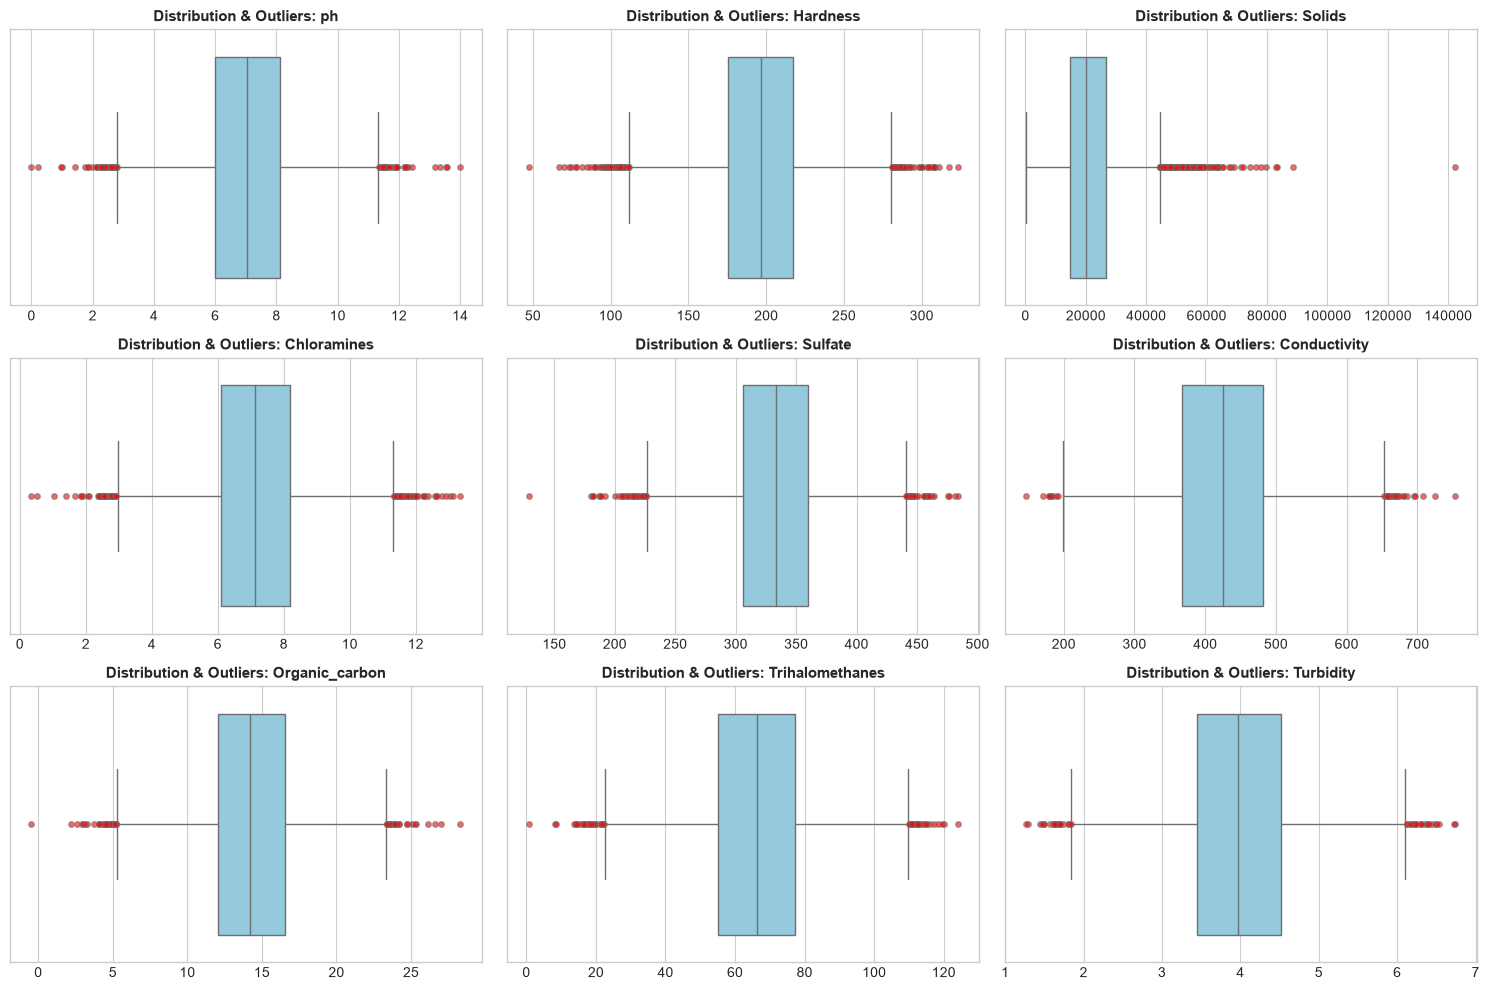

In [12]:
# 3. CONFIGURE PLOTTING STYLE & SUBPLOTS
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten 3x3 matrix into a 1D iterable array of 9 subplots


# --- SECTION 1: VISUALIZE BOXPLOTS BEFORE CAPPING ---
# Boxplots visually expose the median line, IQR box (Q1 to Q3), whiskers (1.5 * IQR),
# and individual flier points (outliers highlighted in red).
for idx, col in enumerate(num_cols):
    sns.boxplot(
        x=df[col], 
        ax=axes[idx], 
        color='skyblue', 
        flierprops=dict(marker='o', markersize=4, markerfacecolor='red', alpha=0.6)
    )
    axes[idx].set_title(f'Distribution & Outliers: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
plt.tight_layout()
plt.show()

In [13]:
# --- SECTION 2: COMPUTE TUKEY'S IQR FENCES & COUNT OUTLIERS ---
outlier_summary = []
iqr_bounds = {}

for col in num_cols:
    # Compute 25th (Q1) and 75th (Q3) percentiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate Tukey's outer fences
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Domain-Knowledge Constraint: Physical concentrations and pH cannot be negative!
    # Fix sensor artifacts (e.g. Organic_carbon < 0.0) by clamping lower fence to 0.0.
    if col in ['ph', 'Organic_carbon', 'Solids', 'Turbidity', 'Chloramines']:
        lower_bound = max(0.0, lower_bound)
        
    # Store calculated boundaries for subsequent transformation
    iqr_bounds[col] = (lower_bound, upper_bound)
    
    # Count rows exceeding fences
    lower_outliers = (df[col] < lower_bound).sum()
    upper_outliers = (df[col] > upper_bound).sum()
    total_outliers = lower_outliers + upper_outliers
    pct_outliers = (total_outliers / len(df)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1 (25%)': round(Q1, 2),
        'Q3 (75%)': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower_bound, 2),
        'Upper Fence': round(upper_bound, 2),
        'Outlier Count': total_outliers,
        'Outlier (%)': round(pct_outliers, 2)
    })

# Format and display the outlier diagnostic report
outlier_report_df = pd.DataFrame(outlier_summary)
print("--- 📊 OUTLIER AUDIT (TUKEY'S FENCES) ---")
print(outlier_report_df.to_string(index=False))

--- 📊 OUTLIER AUDIT (TUKEY'S FENCES) ---
        Feature  Q1 (25%)  Q3 (75%)      IQR  Lower Fence  Upper Fence  Outlier Count  Outlier (%)
             ph      6.00      8.13     2.13         2.80        11.33             72         0.93
       Hardness    175.32    217.54    42.22       111.98       280.87            101         1.30
         Solids  14655.62  26633.43 11977.80         0.00     44600.13            192         2.47
    Chloramines      6.09      8.18     2.09         2.95        11.33             81         1.04
        Sulfate    306.45    360.17    53.72       225.87       440.74             58         0.75
   Conductivity    367.59    481.75   114.16       196.34       653.00             32         0.41
 Organic_carbon     12.03     16.57     4.53         5.23        23.37             56         0.72
Trihalomethanes     55.23     77.13    21.90        22.39       109.98             54         0.69
      Turbidity      3.44      4.51     1.07         1.84         6.

In [14]:
# --- SECTION 3: APPLY IQR CAPPING (WINSORIZATION) ---
# Instead of deleting outlier rows (which would discard ~15-20% of the dataset),
# we cap extreme values at the lower and upper fences using .clip().
# This neutralizes extreme gradient spikes while preserving sample size.
df_clean = df.copy()
for col in num_cols:
    lower_b, upper_b = iqr_bounds[col]
    df_clean[col] = df_clean[col].clip(lower=lower_b, upper=upper_b)

In [15]:
# --- SECTION 4: VERIFY OUTLIER MITIGATION & SKEWNESS DROP ---
# Confirm that extreme maximums were successfully reined in and skewness is normalized.
print("\n--- 📐 SKEWNESS COMPARISON (BEFORE VS AFTER CAPPING) ---")
skew_comparison = pd.DataFrame({
    'Before Capping': df[num_cols].skew().round(3),
    'After Capping': df_clean[num_cols].skew().round(3),
    'Max Before': df[num_cols].max().round(2),
    'Max After (Capped)': df_clean[num_cols].max().round(2),
    'Min Before': df[num_cols].min().round(2),
    'Min After (Capped)': df_clean[num_cols].min().round(2)
})
print(skew_comparison)


--- 📐 SKEWNESS COMPARISON (BEFORE VS AFTER CAPPING) ---
                 Before Capping  After Capping  Max Before  \
ph                        0.010          0.008       14.00   
Hardness                 -0.043         -0.017      323.12   
Solids                    1.390          0.689   142285.08   
Chloramines              -0.004         -0.005       13.35   
Sulfate                  -0.020          0.011      483.57   
Conductivity              0.132          0.117      753.34   
Organic_carbon            0.008          0.012       28.30   
Trihalomethanes          -0.045         -0.032      124.00   
Turbidity                -0.005         -0.005        6.74   

                 Max After (Capped)  Min Before  Min After (Capped)  
ph                            11.33        0.00                2.80  
Hardness                     280.87       47.43              111.98  
Solids                     44600.13      320.94              320.94  
Chloramines                   11.33       

---

### =============================================================
### Step 2.3: Strategic Missing Value Imputation & Distribution Audit
### =============================================================

We audit missingness and compare **Median Imputation** vs. **K-Nearest Neighbors (KNN) Imputation**.
* **Goal**: Retain 100% of sample observations without distorting the underlying physicochemical probability density distributions.
* **Validation**: Plot Before vs. After Kernel Density Estimation (KDE) distributions to ensure zero distribution drift.

In [16]:
# Identify Features Containing Missing Values (NaNs)
missing_features = df_clean.columns[df_clean.isnull().any()].tolist()
print(f"📋 Features Requiring Imputation: {missing_features}")

📋 Features Requiring Imputation: ['ph', 'Sulfate', 'Trihalomethanes']


In [17]:
# --- SECTION 1: MISSINGNESS CO-OCCURENCE AUDIT ---
# Check if rows are missing multiple values simultaneously, which may indicate sensor or lab systemic failures.
null_counts_per_row = df_clean[missing_features].isnull().sum(axis = 1)
row_missingness_dist = null_counts_per_row.value_counts().sort_index()

print("\n--- 🔍 MISSING VALUES PER ROW AUDIT ---")
for missing_count, num_rows in row_missingness_dist.items():
    pct = (num_rows / len(df_clean)) * 100
    print(f"  • Rows missing exactly {missing_count} features: {num_rows:,} ({pct:.2f}%)")


--- 🔍 MISSING VALUES PER ROW AUDIT ---
  • Rows missing exactly 0 features: 4,931 (63.41%)
  • Rows missing exactly 1 features: 2,472 (31.79%)
  • Rows missing exactly 2 features: 358 (4.60%)
  • Rows missing exactly 3 features: 15 (0.19%)


In [18]:
# --- SECTION 2: BENCHMARKING IMPUTATION STRATEGIES ---
# Strategy A: Median Imputer (Robust 1D replacement)
median_imputer = SimpleImputer(strategy = "median") # This means that for each feature with missing values, the median of the non-missing values will be computed and used to fill in the missing entries. This is a robust method that is less sensitive to outliers compared to mean imputation.

df_median_imputed = df_clean.copy()
df_median_imputed[num_cols] = median_imputer.fit_transform(df_clean[num_cols]) # This means that the median imputer is applied to all numerical columns in the df_clean DataFrame, and the resulting imputed values are assigned back to the corresponding columns in df_median_imputed.


# Strategy B: K Nearest Neighbors (KNN) Imputer (Uses multi-feature Euclidean distance from k=5 nearest neighbors)
# KNN Imputer looks at the other 6 complete features (Hardness, Conductivity, etc.) to estimate pH and Sulfate.
knn_imputer = KNNImputer(n_neighbors = 5) # This means that for each missing value, the KNN imputer will find the 5 nearest neighbors (rows) based on the other features and use their values to estimate the missing entry. This method can capture more complex relationships between features compared to simple median imputation.

df_knn_imputed = df_clean.copy()
df_knn_imputed[num_cols] = knn_imputer.fit_transform(df_clean[num_cols]) # This means that the KNN imputer is applied to all numerical columns in the df_clean DataFrame, and the resulting imputed values are assigned back to the corresponding columns in df_knn_imputed.

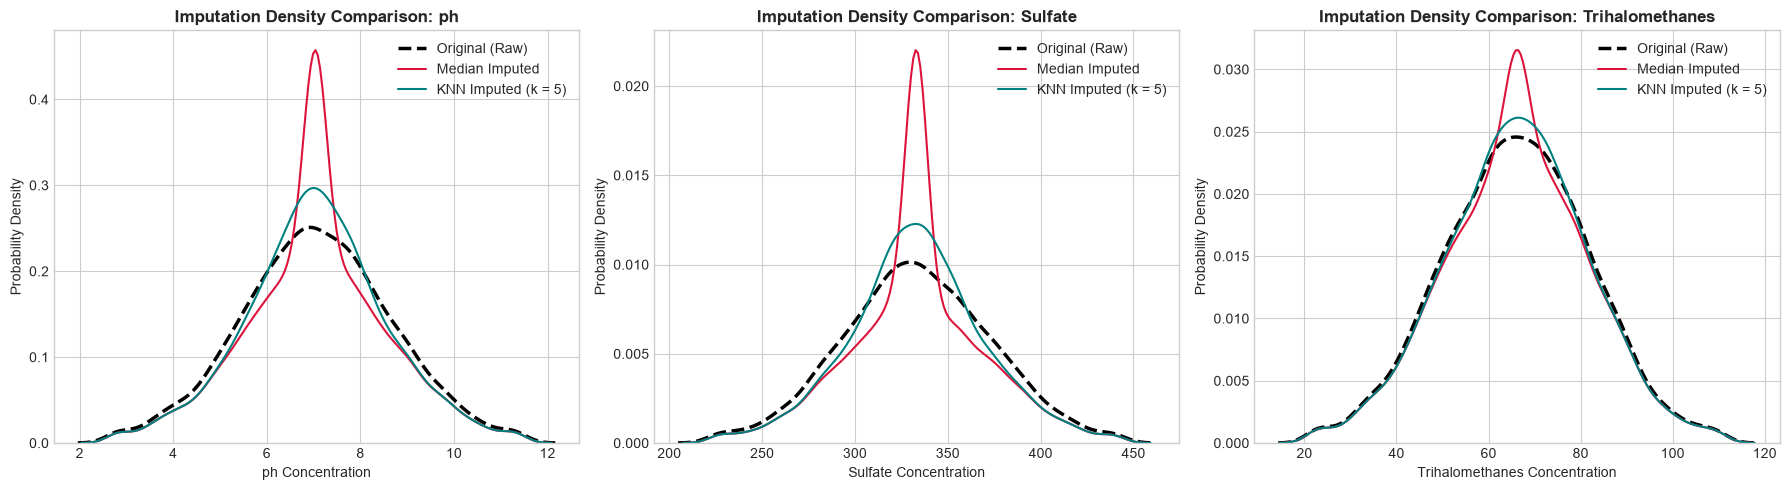

In [19]:
# --- SECTION 3: VISUAL KDE DISTRIBUTION VALIDATION ---
# Kernel Density Estimation (KDE) plots visualize the probability density function of a continuous variable
# An imputation strategy is valid ONLY IF it does not artificially distort the continuous probability density.
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
for idx, col in enumerate(missing_features):
    # Plot original distribution (excluding NaNs)
    sns.kdeplot(df_clean[col].dropna(), ax = axes[idx], label = "Original (Raw)", color = "black", lw = 2.5, linestyle = "--")

    # Plot median Imputed distribution
    sns.kdeplot(df_median_imputed[col], ax = axes[idx], label = "Median Imputed", color = "crimson", lw = 1.5)

    # Plot KNN Imputed distribution
    sns.kdeplot(df_knn_imputed[col], ax = axes[idx], label = "KNN Imputed (k = 5)", color = "teal", lw = 1.5)

    axes[idx].set_title(f"Imputation Density Comparison: {col}", fontsize = 12, fontweight = "bold")
    axes[idx].set_xlabel(f"{col} Concentration")
    axes[idx].set_ylabel("Probability Density")
    axes[idx].legend(loc = "upper right")

plt.tight_layout()
plt.show()

In [20]:

# --- SECTION 4: SELECT BEST IMPUTER & FINALIZE CLEAN DATASET ---
# We adopt KNN Imputation for our master dataset as it preserves multivariate correlations.
df_final_clean = df_knn_imputed.copy()

# Persist cleaned, imputed dataset for Phase 3 Pipeline ingestion
CLEAN_DATA_PATH = "../dataset/cleaned_water_potability.csv" if os.path.exists("../dataset") else "dataset/cleaned_water_potability.csv"
df_final_clean.to_csv(CLEAN_DATA_PATH, index=False)
print("="*100)
print(f"🎉 PHASE 2 COMPLETE: CLEANED & IMPUTED DATASET SAVED TO '{CLEAN_DATA_PATH}'")
print(f"📊 Remaining Null Values in Dataset: {df_final_clean.isnull().sum().sum()}")
print(f"📊 Final Dataset Shape: {df_final_clean.shape[0]} rows × {df_final_clean.shape[1]} columns")
print("="*100)

🎉 PHASE 2 COMPLETE: CLEANED & IMPUTED DATASET SAVED TO '../dataset/cleaned_water_potability.csv'
📊 Remaining Null Values in Dataset: 0
📊 Final Dataset Shape: 7776 rows × 12 columns


---


# ⚙️ Phase 3: Preprocessing Pipeline Architecture

---

### =============================================================
### Step 3.1: Feature-Target Separation & Stratified Train-Test Partitioning
We partition the dataset into an **80% Training Set** and a **20% Held-Out Test Set**.
* **Data Leakage Defense**: The split occurs **BEFORE** fitting any scalers or encoders.
* **Stratification (`stratify=y`)**: Enforces exact target class balance consistency ($68.4\% : 31.6\%$) across both train and test partitions.
### =============================================================

In [21]:
# Load clean dataset from Phase 2
DATA_PATH = "../dataset/cleaned_water_potability.csv" if os.path.exists("../dataset/cleaned_water_potability.csv") else "dataset/cleaned_water_potability.csv"
df_clean = pd.read_csv(DATA_PATH)

In [22]:
# --- SECTION 1: SEPARATE FEATURE MATRIX (X) AND TARGET VECTOR(y) ---
# X contains all 11 independent predictor variables (9 continuous physicochemical parameters and 2 categorical metadata)
X = df_clean.drop(columns=["Potability"])  # Feature matrix (independent variables)

# y contains the ground-truth binary classification label (0 = Unsafe, 1 = Safe)
y = df_clean['Potability']

print(f"📦 Feature Matrix (X) Shape: {X.shape[0]} rows × {X.shape[1]} columns")
print(f"🎯 Target Vector (y) Shape:   {y.shape[0]} rows")

📦 Feature Matrix (X) Shape: 7776 rows × 11 columns
🎯 Target Vector (y) Shape:   7776 rows


In [23]:
# --- SECTION 2: EXECUTE STRATIFIED TRAIN-TEST SPLIT ---
# - test_size=0.20: Allocates 80% (6,220 samples) to training and 20% (1,556 samples) to held-out test.
# - random_state=42: Ensures absolute reproducibility across all experiments.
# - stratify=y: Preserves the exact 68.4% : 31.6% class ratio across both partitions.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

In [24]:
# --- SECTION 3: VERIFY PARTITION INTEGRITY & CLASS BALANCE ---
print("\n" + "="*60)
print("📊 TRAIN-TEST SPLIT SUMMARY")
print("="*60)
print(f"  • Training Feature Set (X_train): {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  • Held-Out Test Set (X_test):      {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Compare class distribution between Train and Test splits
train_dist = y_train.value_counts(normalize = True) * 100
test_dist = y_test.value_counts(normalize = True) * 100

split_audit_df = pd.DataFrame({
    'Train Count': y_train.value_counts(),
    'Train Ratio (%)': train_dist.round(2),
    'Test Count': y_test.value_counts(),
    'Test Ratio (%)': test_dist.round(2)    
})

print("\n--- ⚖️ STRATIFICATION VERIFICATION AUDIT ---")
print(split_audit_df)


📊 TRAIN-TEST SPLIT SUMMARY
  • Training Feature Set (X_train): 6,220 samples (80.0%)
  • Held-Out Test Set (X_test):      1,556 samples (20.0%)

--- ⚖️ STRATIFICATION VERIFICATION AUDIT ---
            Train Count  Train Ratio (%)  Test Count  Test Ratio (%)
Potability                                                          
0                  4255            68.41        1064           68.38
1                  1965            31.59         492           31.62


---

### ===============================================================
### Step 3.2: Unified Preprocessing Pipeline (`ColumnTransformer`)
### ===============================================================

We construct a composite `ColumnTransformer` to process heterogeneous feature types simultaneously:
1. **Numerical Features ($9$)**: Standardized to zero-mean and unit-variance ($z = \frac{x - \mu}{\sigma}$) using `StandardScaler`.
2. **Categorical Features ($2$)**: Encoded into dummy binary variables using `OneHotEncoder(drop='first')` to prevent multicollinearity (the Dummy Variable Trap).
3. **Leak-Free Transformation**: The preprocessor is fitted strictly on `X_train` and applied downstream to `X_test`.

In [28]:
# --- SECTION 1: DYNAMIC FEATURE DISCOVERY ---
# Automatically detect numerical continuous columns (exclude target)
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
# Automatically detect string / categorical metadata columns
categorical_features = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
print(f"📋 Auto-Detected Numerical Features ({len(numeric_features)}): {numeric_features}")
print(f"📋 Auto-Detected Categorical Features ({len(categorical_features)}): {categorical_features}")

📋 Auto-Detected Numerical Features (9): ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
📋 Auto-Detected Categorical Features (2): ['Data_Source', 'Station_Type']


In [29]:
# --- SECTION 2: CONSTRUCT THE COMPOSITE COLUMN TRANSFORMER ---
# - StandardScaler(): Scales each numerical column so mean = 0.0 and std = 1.0.
# - OneHotEncoder(drop='first', handle_unknown='ignore'):
#     * drop='first': Drops the first dummy category per feature to prevent multicollinearity (Dummy Variable Trap).
#     * handle_unknown='ignore': Ensures pipeline resilience if an unseen category appears in production.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Keep any unlisted columns untouched
)

In [30]:
# --- SECTION 3: FIT ON TRAIN & TRANSFORM BOTH PARTITIONS ---
# CRITICAL: We fit strictly on X_train to learn training statistics, then transform both sets.
print("\n⚙️ Fitting Preprocessor on X_train...")
X_train_proc = preprocessor.fit_transform(X_train)
print("⚙️ Transforming X_test using learned X_train parameters...")
X_test_proc = preprocessor.transform(X_test)


⚙️ Fitting Preprocessor on X_train...
⚙️ Transforming X_test using learned X_train parameters...


In [32]:
# --- SECTION 4: EXTRACT INTERPRETABLE FEATURE NAMES ---
# Extract human-readable column names after one-hot expansion
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)
# Convert numpy arrays back to DataFrames for inspection and model training
X_train_df = pd.DataFrame(X_train_proc, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_proc, columns=all_feature_names, index=X_test.index)

In [33]:
# --- SECTION 5: PIPELINE VERIFICATION & SANITY AUDIT ---
print("\n" + "="*60)
print("🎉 PREPROCESSING PIPELINE EXECUTION COMPLETE")
print("="*60)
print(f"  • Preprocessed Training Shape (X_train_df): {X_train_df.shape[0]} samples × {X_train_df.shape[1]} features")
print(f"  • Preprocessed Test Shape (X_test_df):     {X_test_df.shape[0]} samples × {X_test_df.shape[1]} features")
print("\n--- 📋 POST-ENCODING FEATURE SPACE (15 TOTAL FEATURES) ---")
for i, feat in enumerate(all_feature_names, 1):
    print(f"  {i:02d}. {feat}")
# Verify that numerical features have Mean ≈ 0 and Std ≈ 1 on the training set
print("\n--- 🔍 SCALER SANITY CHECK (TRAIN MEAN & STD) ---")
scaler_check = pd.DataFrame({
    'Train Mean (Expected ≈ 0)': X_train_df[numeric_features].mean().round(4),
    'Train Std (Expected ≈ 1)': X_train_df[numeric_features].std().round(4),
    'Test Mean (Slightly != 0)': X_test_df[numeric_features].mean().round(4),
    'Test Std (Slightly != 1)': X_test_df[numeric_features].std().round(4)
})
print(scaler_check)


🎉 PREPROCESSING PIPELINE EXECUTION COMPLETE
  • Preprocessed Training Shape (X_train_df): 6220 samples × 15 features
  • Preprocessed Test Shape (X_test_df):     1556 samples × 15 features

--- 📋 POST-ENCODING FEATURE SPACE (15 TOTAL FEATURES) ---
  01. ph
  02. Hardness
  03. Solids
  04. Chloramines
  05. Sulfate
  06. Conductivity
  07. Organic_carbon
  08. Trihalomethanes
  09. Turbidity
  10. Data_Source_Regional_Network_B
  11. Station_Type_Industrial_Catchment
  12. Station_Type_Natural_Lake
  13. Station_Type_Reservoir
  14. Station_Type_River_Basin
  15. Station_Type_Urban_Treatment

--- 🔍 SCALER SANITY CHECK (TRAIN MEAN & STD) ---
                 Train Mean (Expected ≈ 0)  Train Std (Expected ≈ 1)  \
ph                                    -0.0                    1.0001   
Hardness                              -0.0                    1.0001   
Solids                                -0.0                    1.0001   
Chloramines                            0.0                    

---